## Clustering Analysis of Sensitivity, Resilience, and Exposure (S-R-E) Scores for Vulnerability Interpretation

To further interpret the multidimensional structure of financial vulnerability, **K-means clustering** is applied to the Sensitivity, Resilience, and Exposure (S-R-E) scores as an exploratory analytical step. While the RFVI ranks regions by overall vulnerability, clustering groups observations based on *how that vulnerability is formed*. The workflow converts monthly RFVI datasets into a clustering-ready format, identifies meaningful cluster solutions, and produces a final dataset suitable for visualization and reporting.

Workflow Overview:

1) Master Dataset Construction and Standardization

- Consolidates all monthly RFVI datasets into a single master file.
- Ensures numerical consistency and generates standardized S-R-E scores for comparability.
- Includes variables like Urban-RuralFIES when available to enhance interpretability.

2) K-Means Cluster Diagnostics

- Aggregates observations into unique snapshots for analysis.
- Tests K = 2 to 10 to evaluate cluster cohesion and separation using elbow and silhouette metrics.
- Provides visual guidance for selecting the optimal number of clusters.

3) K-Means Cluster Generation and Visualization

- Assigns clusters based on the selected K value.
- Visualizes cluster profiles via bar charts and pair plots to examine structural differences.
- Facilitates interpretation of vulnerability typologies and comparison of alternative solutions.

4) Final Dataset for Dashboard

- Merges cluster assignments with RFVI and relevant variables.
- Produces a ready-to-use, consolidated dataset for reporting, visualization, and dashboard integration.

The final CSV file `FINAL_Vulnerability_Data.csv` is saved in the `Survey Data with Factor Scores and RFVI` folder

---
### Master Dataset Construction and Standardization

This merges all monthly RFVI datasets into a single master file and prepares it for clustering analysis.

**Key steps:**
- Stacks all monthly files while preserving variables in the analysis (year, month, urban-rural information)
- Ensures numeric consistency for S-R-E scores to prevent errors in downstream analysis
- Generates global standardized scores (Z-scores) for Sensitivity, Resilience, and Exposure, allowing K-Means clustering to be comparable across survey periods

Note: The **Urban-RuralFIES** variable has been included even though it is only present in some survey months, providing an additional dimension for interpretation where available.

Purpose:

To create a clustering-ready, consolidated dataset that maintains all relevant information, ensures numerical consistency, and standardizes S-R-E scores for robust multivariate analysis.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import gc
import os
from sklearn.preprocessing import StandardScaler

# --- 1. LOAD CONFIGURATION ---
try:
    with open(Path("./data/interim/config.json")) as f:
        cfg = json.load(f)
    
    BASE_PATH = Path(cfg["BASE_PATH"])
    SOURCE_DIR = BASE_PATH / "Survey Data with Factor Scores and RFVI"
    OUTPUT_MASTER = Path("./data/processed/merged_data_complete_observations.csv")
    
    print(f" Configuration Loaded.")
    print(f" Source Directory: {SOURCE_DIR}")
except Exception as e:
    print(f" Error loading config: {e}")
    raise

# --- 2. DEFINE TARGET COLUMNS ---
index_cols = [
    'Region', 'Province', 'City_Municipality', 
    'Sensitivity_Score', 'Resilience_Score', 'Exposure_Score', 
    'Sensitivity_norm', 'Resilience_norm', 'Exposure_norm', 'RFVI'
]

continuous_vars = [
    'Normal Working Hours per Day', 
    'Total Hours Worked for all Jobs', 
    'Household Size'
]

categorical_vars = [
    'Work Indicator', 'C04-Sex', 'Available for Work', 'Look for Additional Work',
    'Looked for Work or Tried to Establish Business During the Past Week',
    'Previous Job Indicator', 'Want More Hours of Work', 'Other Job Indicator',
    'C03-Relationship to Household Head', 'C06-Marital Status',
    'New Employment Criteria (jul 05, 2005)', 'C05-Age as of Last Birthday'
]

target_cols = index_cols + continuous_vars + categorical_vars

def build_lossless_master():
    # Ensure output directory exists
    OUTPUT_MASTER.parent.mkdir(parents=True, exist_ok=True)
    
    # Start fresh
    if OUTPUT_MASTER.exists():
        os.remove(OUTPUT_MASTER)

    all_files = list(SOURCE_DIR.rglob("RFVI_*.csv"))
    
    if not all_files:
        print(" No files found!")
        return

    # --- PHASE 1: LOSSLESS MERGE ---
    print(f" Phase 1: Merging {len(all_files)} files into Master...")
    total_rows = 0
    column_order = None 

    for i, f in enumerate(all_files):
        try:
            folder_name = f.parent.name
            parts = folder_name.split('_')
            if len(parts) < 2: continue

            year_val, month_val = parts[0], parts[1]
            header = pd.read_csv(f, nrows=0).columns.tolist()
            current_targets = target_cols.copy()
            
            has_ur = "Urban-RuralFIES" in header
            if has_ur: current_targets.append("Urban-RuralFIES")

            # Read and force numeric types for factor scores to prevent clustering errors
            df = pd.read_csv(f, usecols=current_targets, low_memory=False)
            
            score_cols = ['Sensitivity_Score', 'Resilience_Score', 'Exposure_Score', 
                          'Sensitivity_norm', 'Resilience_norm', 'Exposure_norm']
            for col in score_cols:
                df[col] = pd.to_numeric(df[col], errors='coerce')

            if not has_ur: df['Urban-RuralFIES'] = "Unknown"
            df['Survey Year'] = int(year_val)
            df['Survey Month'] = month_val

            if column_order is None: column_order = df.columns.tolist()
            df = df[column_order]

            # Append to disk
            df.to_csv(OUTPUT_MASTER, index=False, mode='a', header=not OUTPUT_MASTER.exists())
            total_rows += len(df)
            
            print(f"   [{i+1}/{len(all_files)}] Stacked {len(df):,} rows...".ljust(60), end="\r")
            del df
            gc.collect()

        except Exception as e:
            print(f"\n Error processing {f.name}: {e}")

    # --- PHASE 2: GLOBAL STANDARDIZATION (Preparation for Clustering) ---
    # This step is critical for K-Means to work across multiple years
    print(f"\n\n Phase 2: Generating Global Standardized Scores (_std)...")
    
    # Load raw scores to calculate global Z-scores
    raw_score_cols = ['Sensitivity_Score', 'Resilience_Score', 'Exposure_Score']
    df_temp = pd.read_csv(OUTPUT_MASTER, usecols=raw_score_cols)
    
    scaler = StandardScaler()
    # Filling NaNs with 0 (the mean) to ensure the scaler doesn't break
    scaled_data = scaler.fit_transform(df_temp.fillna(0)) 
    
    # Attach these as new columns to the Master file
    print("   Finalizing master file with clustering-ready columns...")
    df_full = pd.read_csv(OUTPUT_MASTER)
    df_full['Sensitivity_std'] = scaled_data[:, 0]
    df_full['Resilience_std'] = scaled_data[:, 1]
    df_full['Exposure_std'] = scaled_data[:, 2]
    
    df_full.to_csv(OUTPUT_MASTER, index=False)

    print(f"\n PROCESS COMPLETE.")
    print(f" Master File Saved: {OUTPUT_MASTER}")
    print(f" Total Rows Consolidated: {total_rows:,}")
    
    # Verification
    print("\n--- MASTER FILE COLUMN CHECK ---")
    preview_df = pd.read_csv(OUTPUT_MASTER, nrows=5)
    print("Columns available for Clustering:", [c for c in preview_df.columns if '_std' in c])
    with pd.option_context('display.max_columns', None, 'display.width', 1000):
        print(preview_df.head())

if __name__ == "__main__":
    build_lossless_master()

 Configuration Loaded.
 Source Directory: H:\.shortcut-targets-by-id\1VctTphaltRx4xcPxmTJlRTrxLalyuEt8\Labor Force Survey\Survey Data with Factor Scores and RFVI
 Phase 1: Merging 40 files into Master...
   [40/40] Stacked 43,717 rows...                           

 Phase 2: Generating Global Standardized Scores (_std)...
   Finalizing master file with clustering-ready columns...

 PROCESS COMPLETE.
 Master File Saved: data\processed\merged_data_complete_observations.csv
 Total Rows Consolidated: 5,986,548

--- MASTER FILE COLUMN CHECK ---
Columns available for Clustering: ['Sensitivity_std', 'Resilience_std', 'Exposure_std']
  Province Urban-RuralFIES City_Municipality Work Indicator C04-Sex                                  Region Available for Work Look for Additional Work Looked for Work or Tried to Establish Business During the Past Week Previous Job Indicator Want More Hours of Work Other Job Indicator C03-Relationship to Household Head             C06-Marital Status New Employmen

---
### K-Means Cluster Diagnostics for City-Level Observations

This code performs preliminary diagnostics to identify the optimal number of clusters for city-level S-R-E profiles.

Key Steps:
- Aggregates the master dataset into unique city-month observations with standardized S-R-E scores.
- Runs K-Means clustering simulations for K = 2 to 10.
- Calculates **within-cluster sum of squares (WCSS)** for the elbow method and **silhouette scores** to evaluate cluster cohesion and separation.
- Generates visualizations to compare both methods and recommend the optimal cluster count.

Purpose:

To provide a data-driven basis for selecting the number of clusters, ensuring meaningful and well-separated vulnerability typologies for subsequent city-level analysis.

 Loading Master Data for City-Level Diagnostics...
 Aggregating into unique City-Month snapshots...
 Running simulations on 31,116 city-monthly observations...
K     | Inertia (Elbow)    | Silhouette Score  
---------------------------------------------
2     | 14493.72           | 0.3212            
3     | 9932.90            | 0.4661            
4     | 7340.38            | 0.3725            
5     | 6109.18            | 0.3624            
6     | 5073.53            | 0.3706            
7     | 4481.80            | 0.3250            
8     | 4029.49            | 0.3235            
9     | 3623.84            | 0.3198            
10    | 3275.44            | 0.3196            


C:\Users\Faith\AppData\Local\Temp\ipykernel_23232\601501240.py:68: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_range, wcss, 'bo-', color='teal', markersize=8, linewidth=2, markeredgecolor='black')
C:\Users\Faith\AppData\Local\Temp\ipykernel_23232\601501240.py:78: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(k_range, silhouette_avg, 'ro-', color='crimson', markersize=8, linewidth=2, markeredgecolor='black')


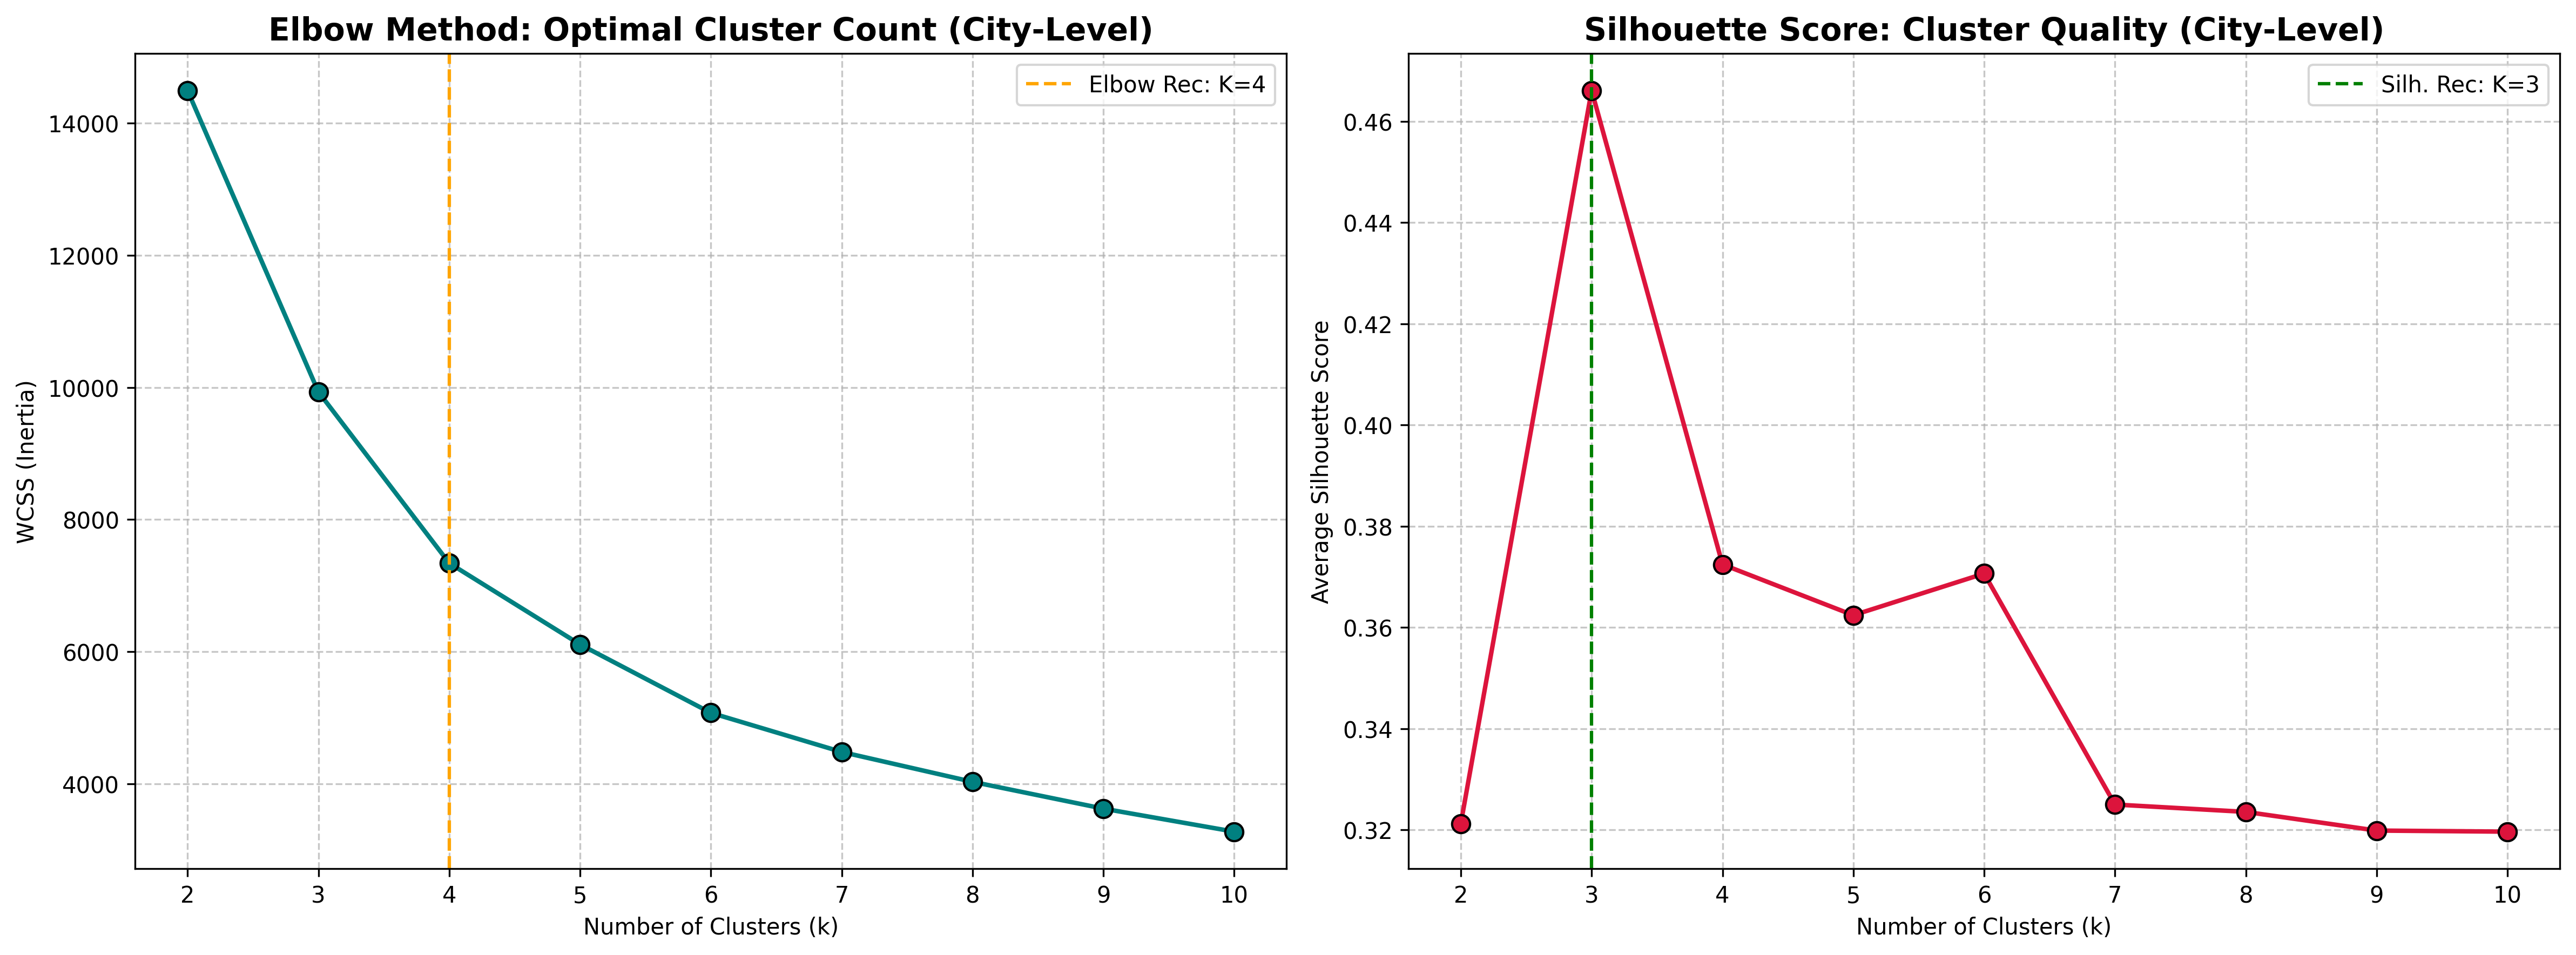

---------------------------------------------
 Diagnostics Complete for 31,116 city-month data points.
 Elbow Recommendation: K=4
 Silhouette Recommendation: K=3
---------------------------------------------


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- 1. PREPARE THE "DOTS" (City-Province-Monthly Snapshots) ---
MASTER_PATH = "./data/processed/merged_data_complete_observations.csv"
features_std = ['Sensitivity_std', 'Resilience_std', 'Exposure_std']
# Geographic hierarchy keys to match your final clustering logic
geo_keys = ['Region', 'Province', 'City_Municipality', 'Survey Year', 'Survey Month']

# Set global resolution to 300 DPI for thesis-quality charts
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

print(" Loading Master Data for City-Level Diagnostics...")
try:
    df_raw = pd.read_csv(MASTER_PATH, usecols=geo_keys + features_std)
except ValueError as e:
    print(f" Error: Missing columns. Ensure the master file has Region, Province, and City_Municipality.")
    raise e

print(f" Aggregating into unique City-Month snapshots...")
# Aggregating by the full hierarchy ensures 'Unknown City' points stay distinct per Province
df_dots = df_raw.groupby(geo_keys)[features_std].mean().reset_index()

# This is our input for the clustering math (X)
X = df_dots[features_std]

# --- 2. RUN K-MEANS SIMULATIONS (K=2 to K=10) ---
wcss = [] 
silhouette_avg = []
k_range = range(2, 11)

print(f" Running simulations on {len(df_dots):,} city-monthly observations...")
print(f"{'K':<5} | {'Inertia (Elbow)':<18} | {'Silhouette Score':<18}")
print("-" * 45)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    current_inertia = kmeans.inertia_
    wcss.append(current_inertia)
    
    current_silhouette = silhouette_score(X, cluster_labels)
    silhouette_avg.append(current_silhouette)
    
    print(f"{k:<5} | {current_inertia:<18.2f} | {current_silhouette:<18.4f}")

# --- 3. CALCULATE RECOMMENDATIONS ---

# 1. Silhouette Recommendation: The absolute peak
optimal_k_sil = list(k_range)[np.argmax(silhouette_avg)]

# 2. Elbow Recommendation: Using the "Ratio of Differences" 
diffs = np.diff(wcss)
diff_ratios = diffs[:-1] / diffs[1:]
optimal_k_elbow = list(k_range)[np.argmax(diff_ratios) + 1]

# --- 4. VISUALIZATION ---
plt.figure(figsize=(16, 6))

# CHART 1: ELBOW METHOD
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bo-', color='teal', markersize=8, linewidth=2, markeredgecolor='black')
plt.axvline(x=optimal_k_elbow, color='orange', linestyle='--', label=f'Elbow Rec: K={optimal_k_elbow}')
plt.title('Elbow Method: Optimal Cluster Count (City-Level)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# CHART 2: SILHOUETTE SCORE
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_avg, 'ro-', color='crimson', markersize=8, linewidth=2, markeredgecolor='black')
plt.axvline(x=optimal_k_sil, color='green', linestyle='--', label=f'Silh. Rec: K={optimal_k_sil}')
plt.title('Silhouette Score: Cluster Quality (City-Level)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# --- 5. FINAL SUMMARY ---
print("-" * 45)
print(f" Diagnostics Complete for {len(df_dots):,} city-month data points.")
print(f" Elbow Recommendation: K={optimal_k_elbow}")
print(f" Silhouette Recommendation: K={optimal_k_sil}")
print("-" * 45)

---
### K-Means Cluster Generation and Profile Visualization

City-level vulnerability typologies are generated using K-Means clustering, guided by the candidate K values identified from the previous diagnostic analysis.

Key Steps:
- Aggregates city-month snapshots with standardized and normalized S-R-E scores.
- Assigns clusters based on the selected number of clusters (K) from the elbow and silhouette diagnostics.
- Visualizes cluster characteristics using:
  - Bar charts of mean Sensitivity, Resilience, and Exposure scores per cluster
  - Pair plots to assess cluster separation and overlap

Purpose:

To identify interpretable vulnerability typologies, evaluate structural differences among clusters, and compare alternative cluster solutions for meaningful insights.

 Loading and Aggregating City-Month Snapshots...

 GENERATING TYPOLOGY FOR K=3


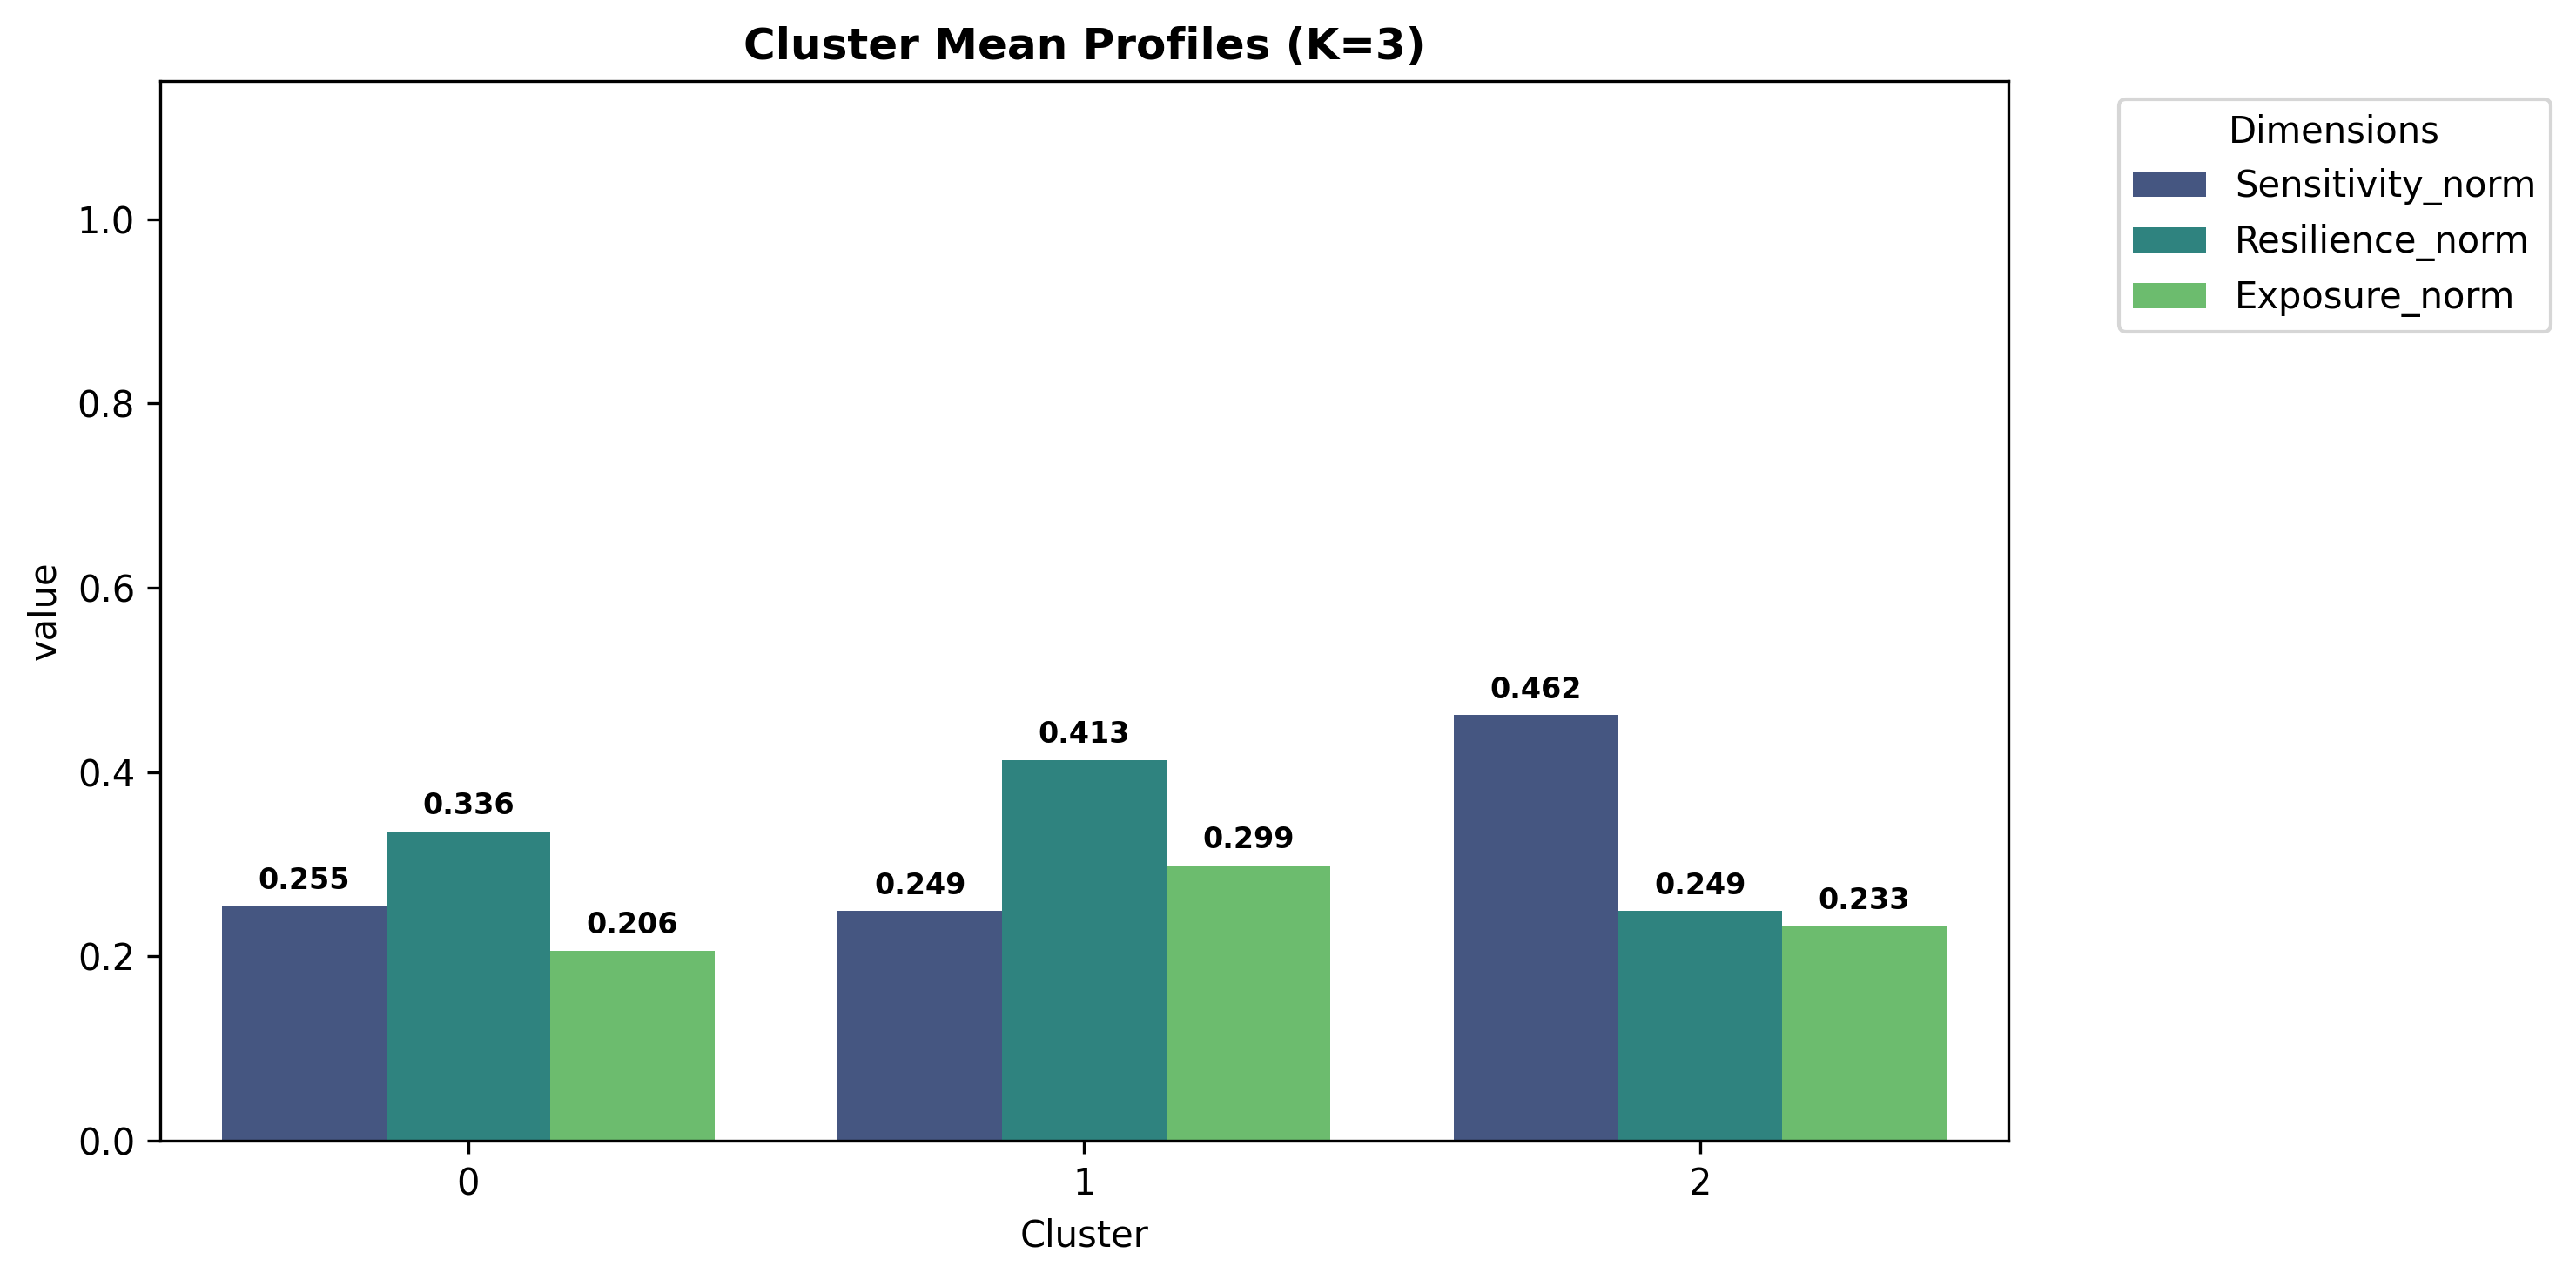

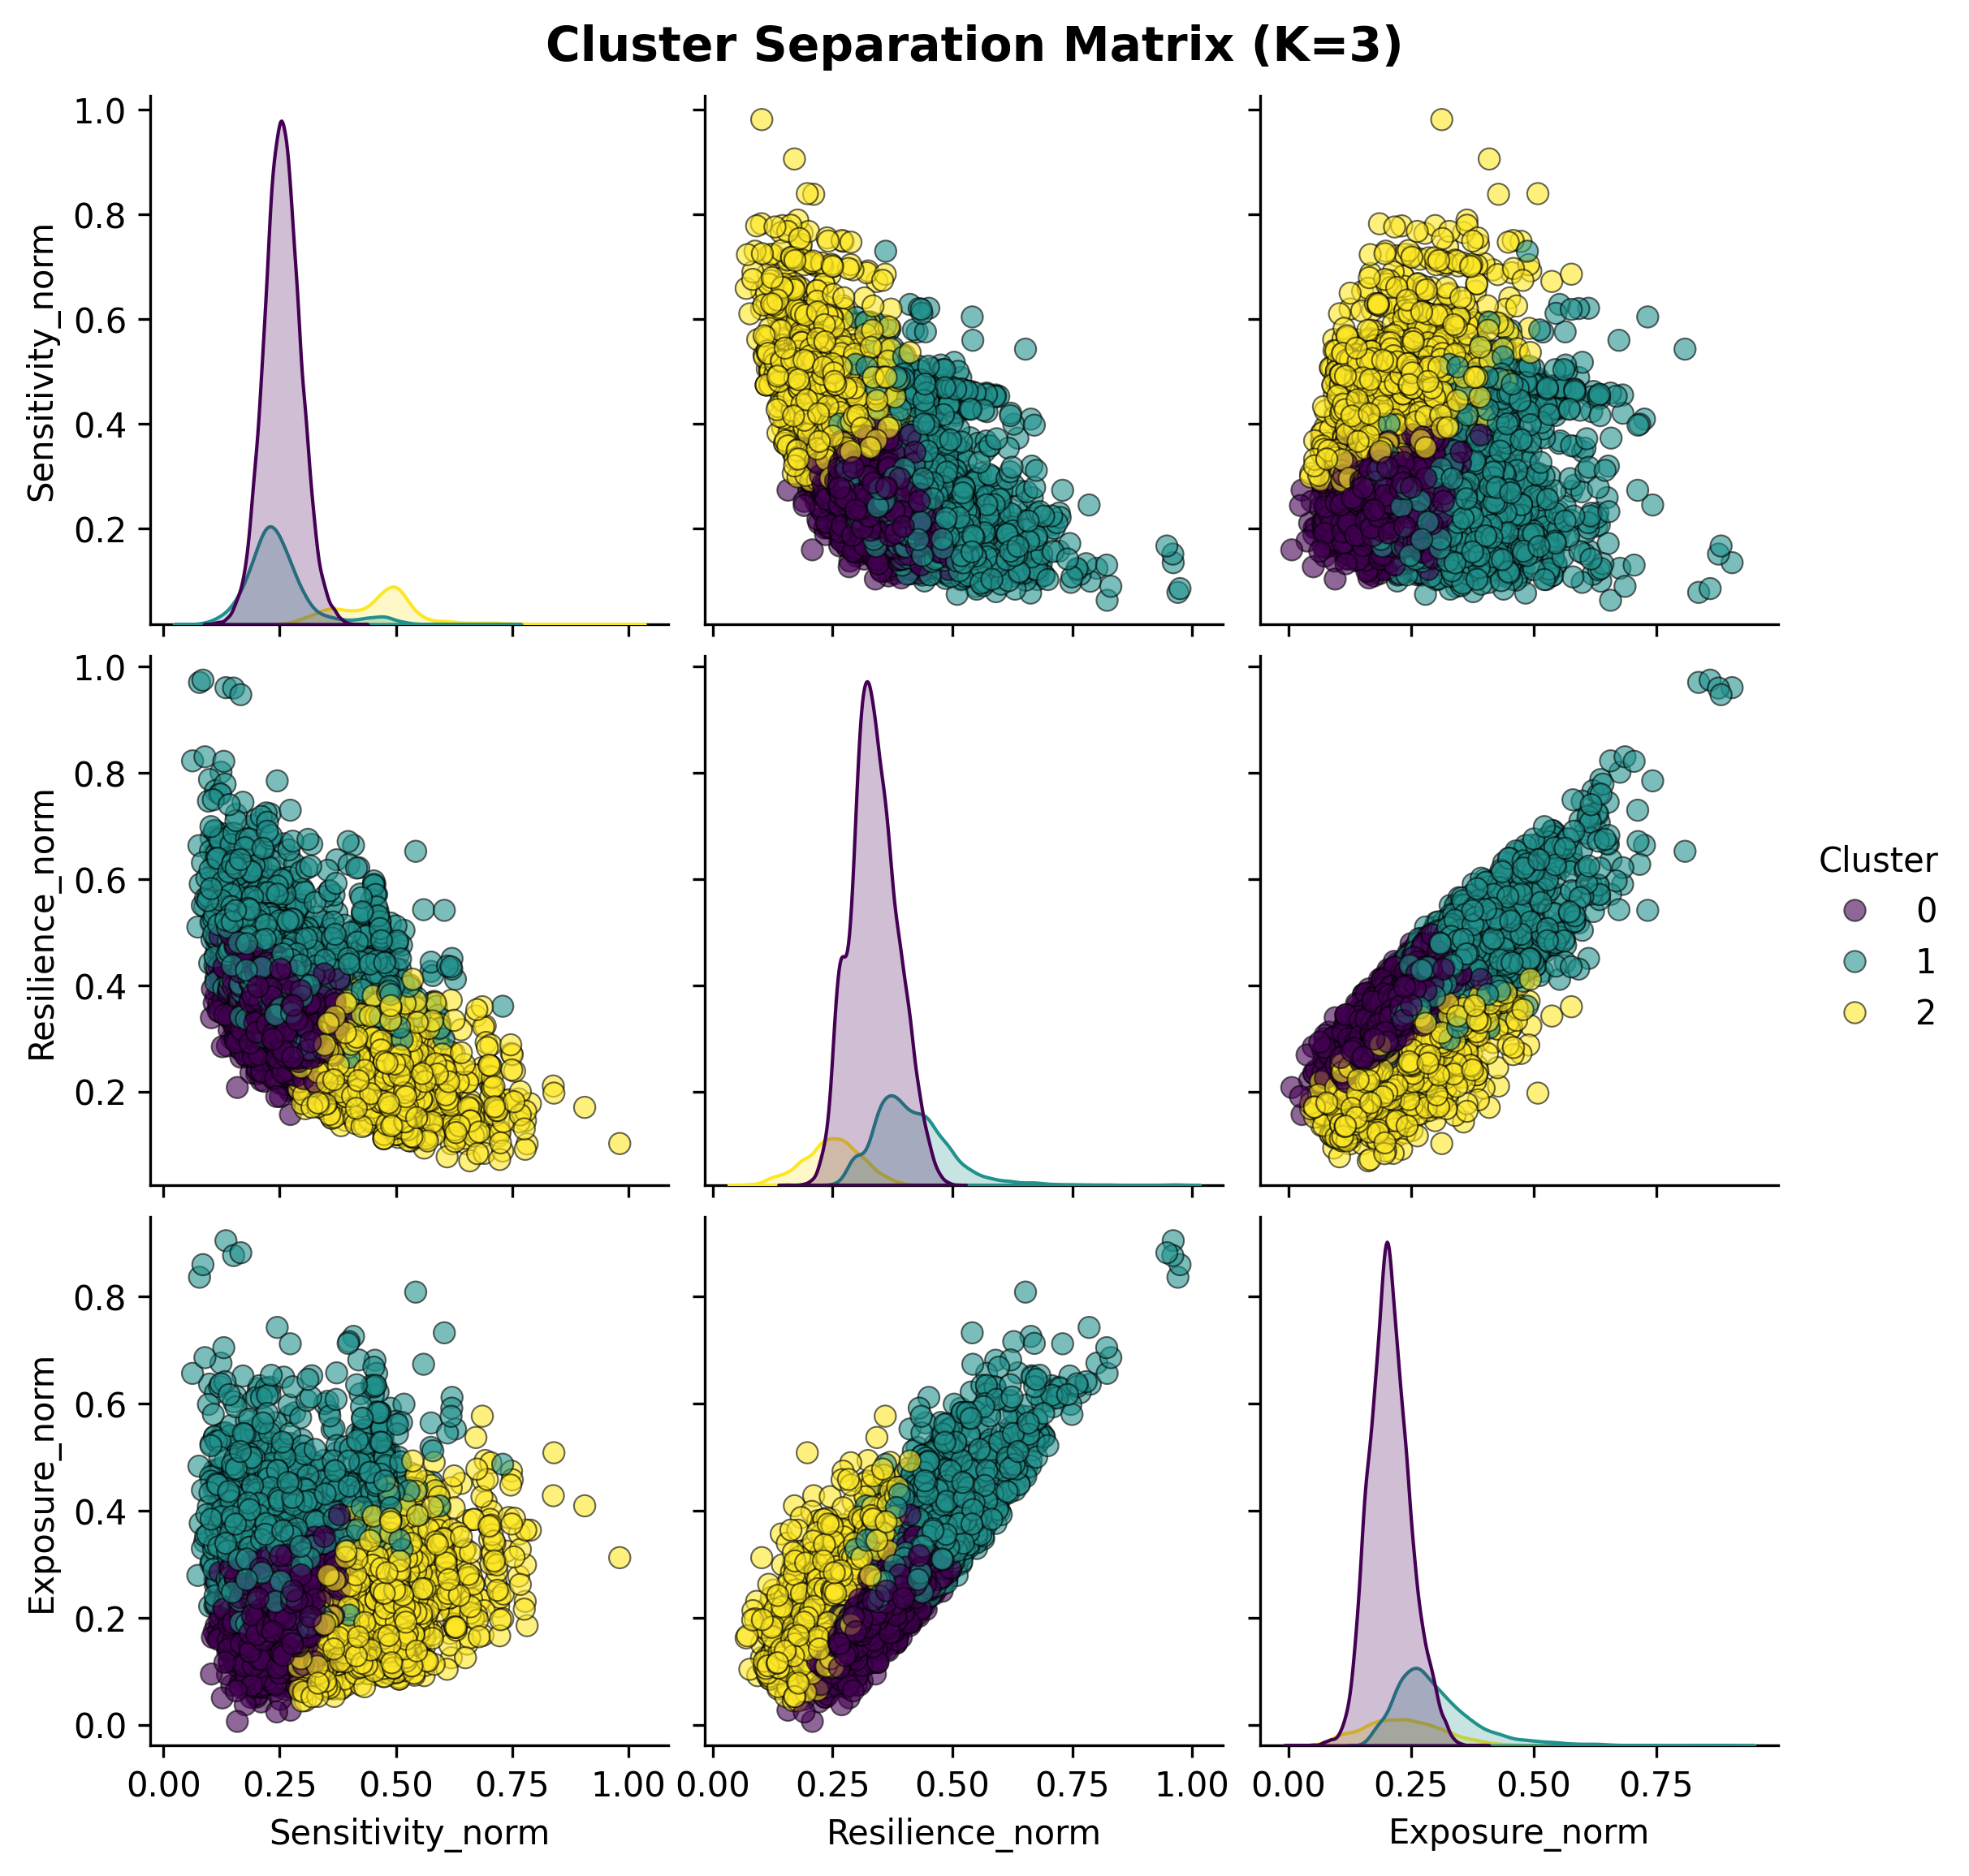


 GENERATING TYPOLOGY FOR K=4


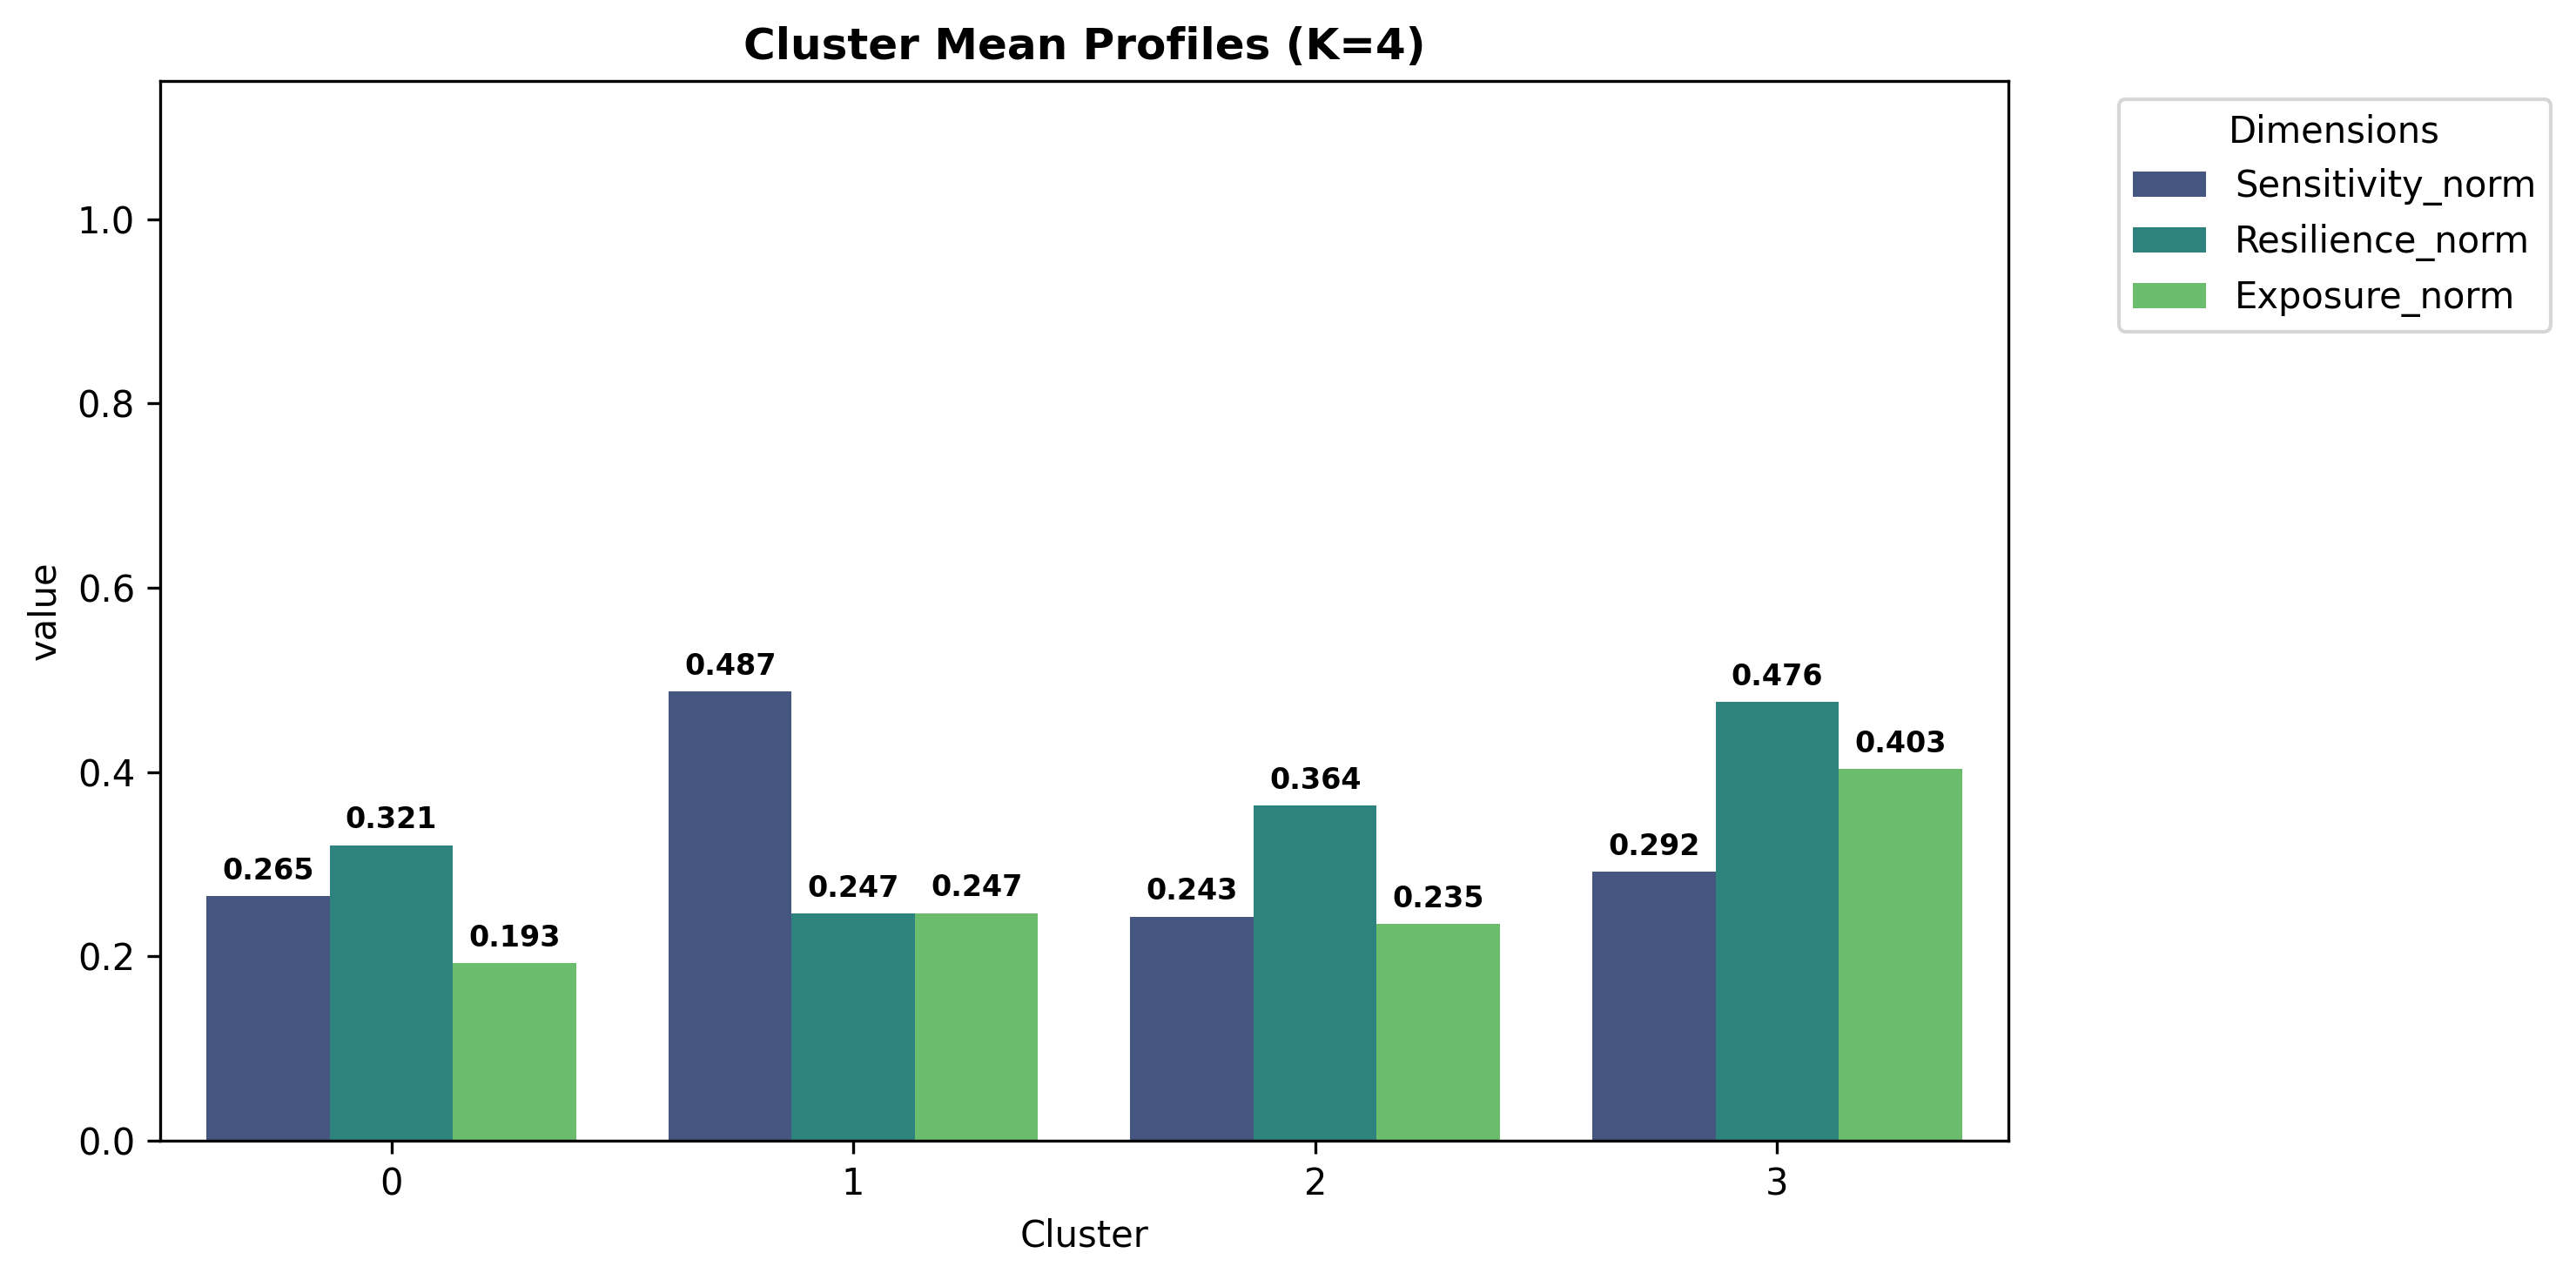

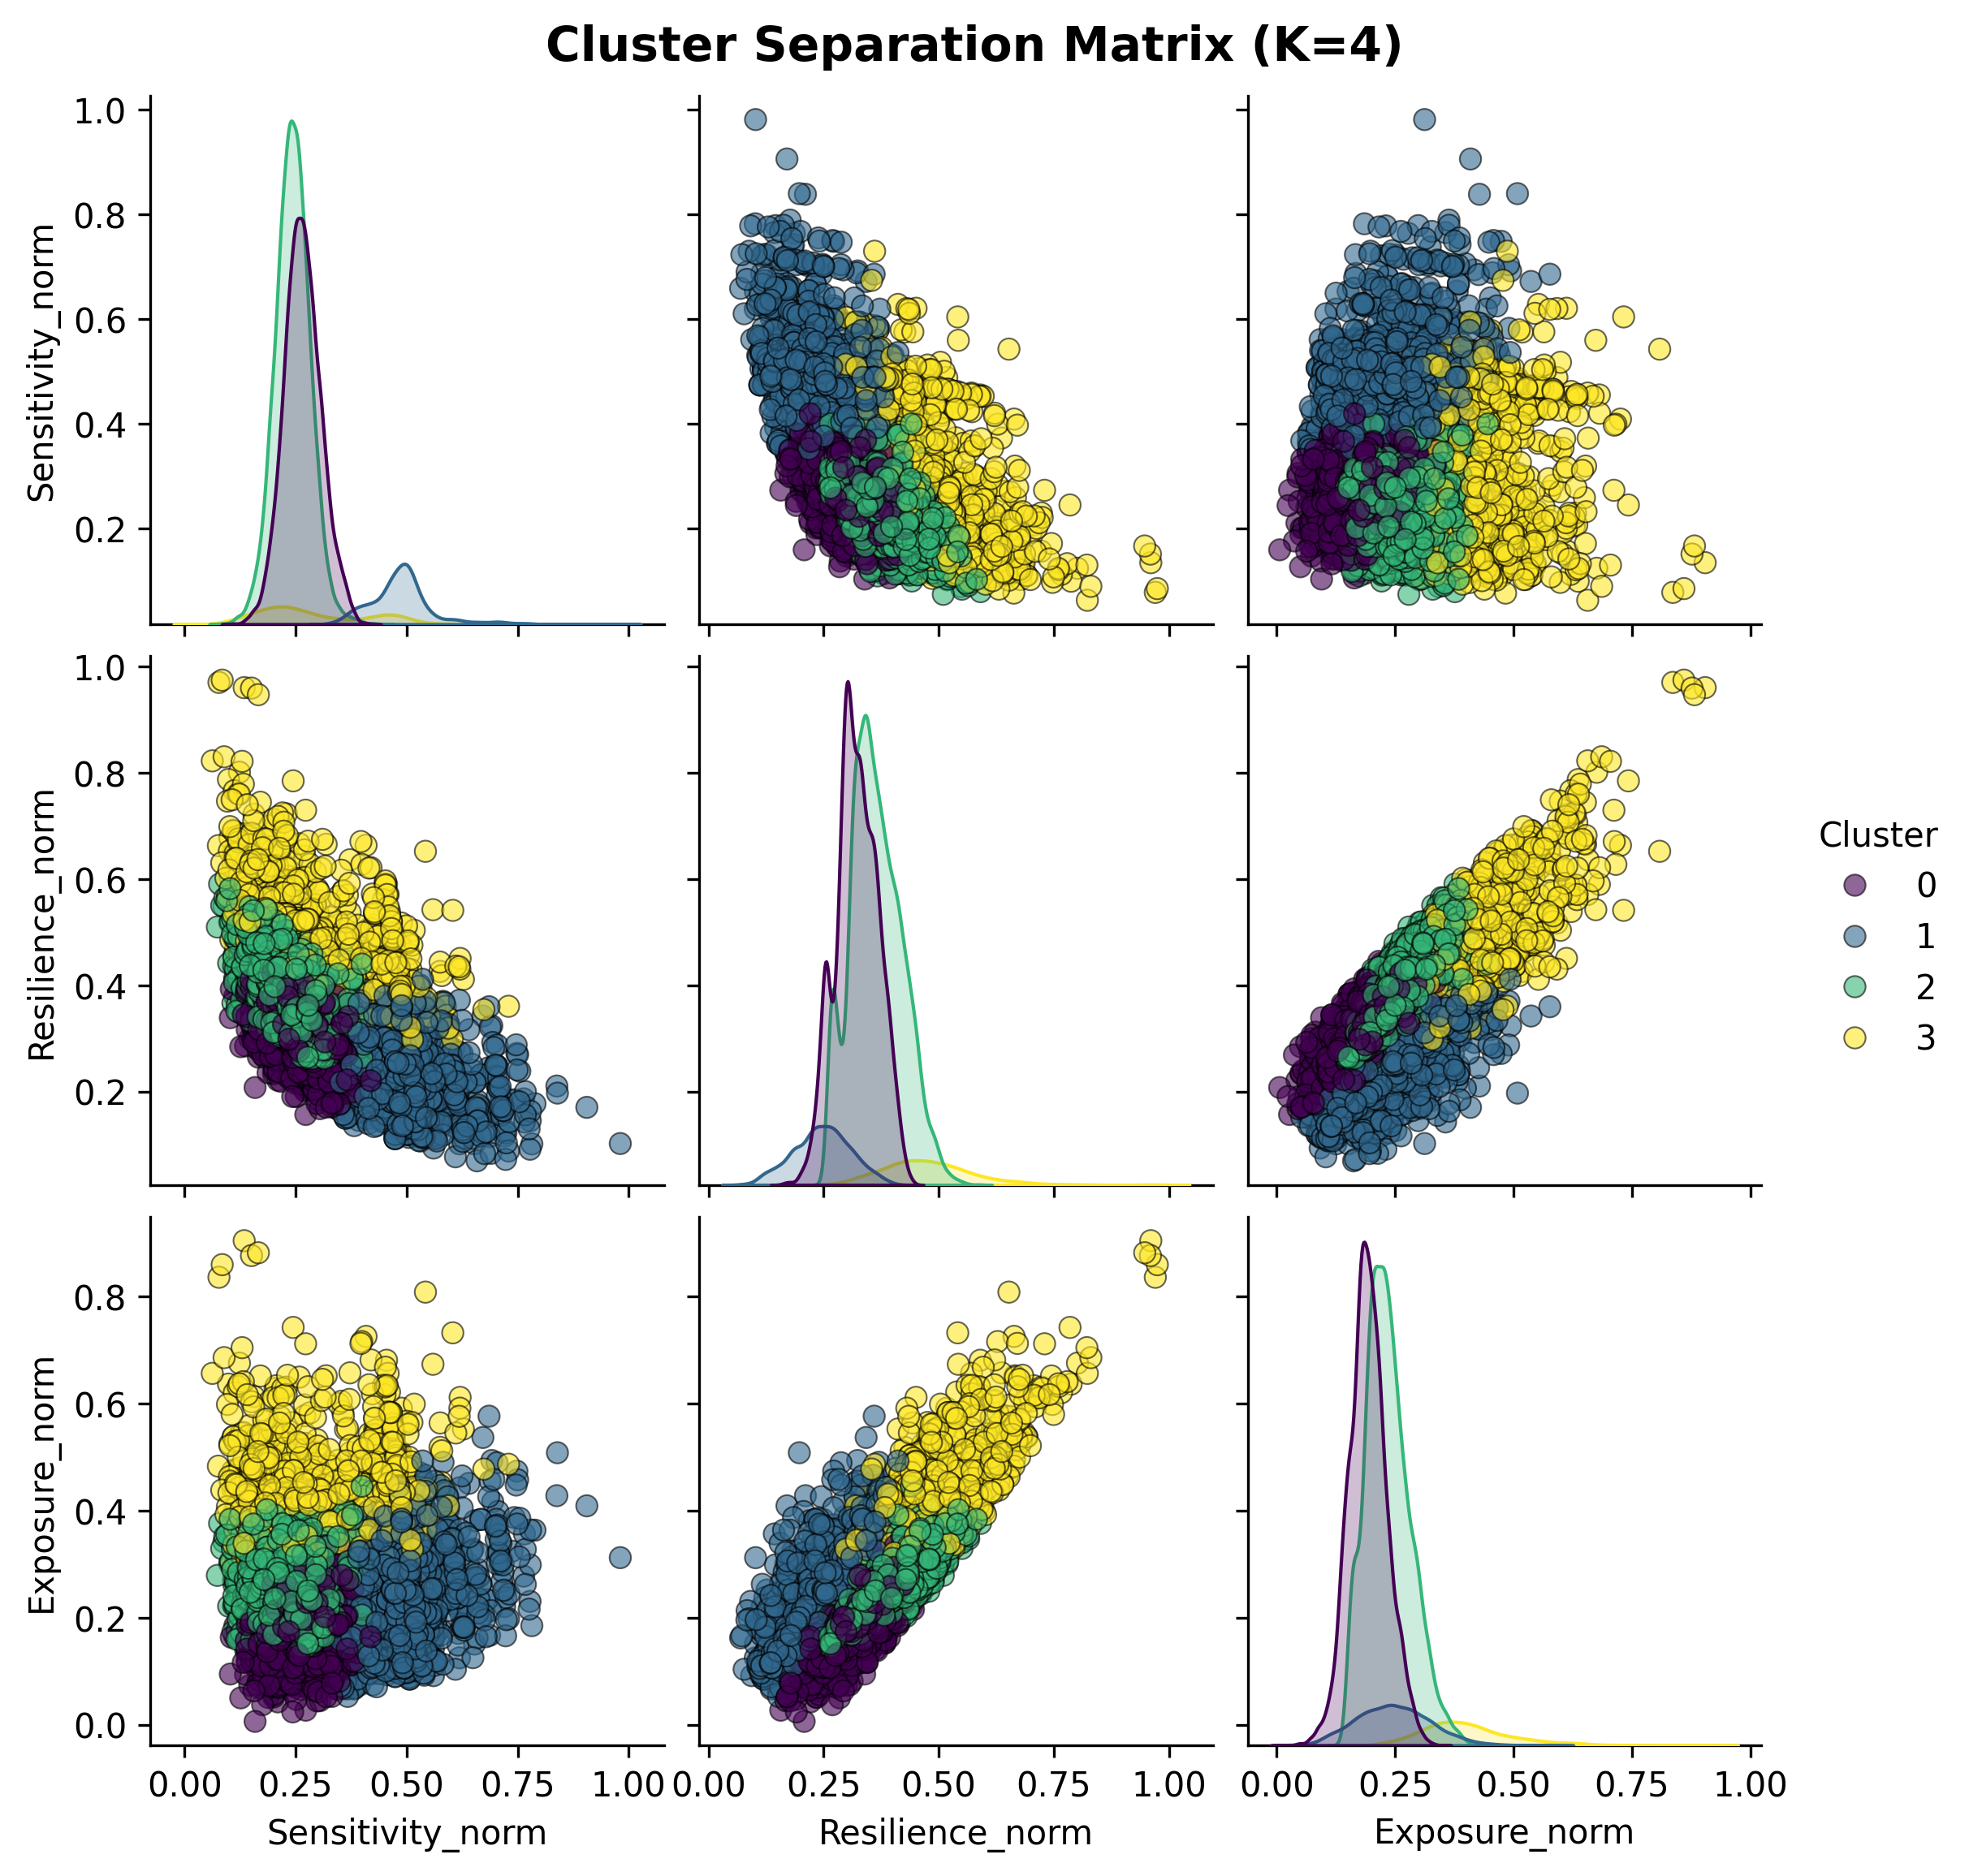

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# --- 1. SETTINGS & FEATURES ---
MASTER_PATH = "./data/processed/merged_data_complete_observations.csv"
clustering_features = ['Sensitivity_std', 'Resilience_std', 'Exposure_std']
viz_features = ['Sensitivity_norm', 'Resilience_norm', 'Exposure_norm']
aggregation_key = ['Region', 'Province', 'City_Municipality', 'Survey Year', 'Survey Month']

# Set global figure resolution to 300 DPI for quality dots
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

print(" Loading and Aggregating City-Month Snapshots...")

# --- 2. DATA PREPARATION ---
try:
    df_raw = pd.read_csv(MASTER_PATH, usecols=aggregation_key + clustering_features + viz_features)
except ValueError as e:
    print(f" Error: Missing columns. Ensure Phase 2 (Standardization) was run.")
    raise e

# Aggregate by full geo-hierarchy to keep "Unknown City" points distinct per Province
df_dots = df_raw.groupby(aggregation_key)[clustering_features + viz_features].mean().reset_index()
X = df_dots[clustering_features]

def generate_vulnerability_comparison(k_value):
    print(f"\n" + "="*60)
    print(f" GENERATING TYPOLOGY FOR K={k_value}")
    print("="*60)
    
    kmeans = KMeans(n_clusters=k_value, init='k-means++', random_state=42, n_init=10)
    df_temp = df_dots.copy()
    df_temp['Cluster'] = kmeans.fit_predict(X)
    
    # --- VISUALIZATION 1: CLUSTER PROFILES (Bar Chart) ---
    cluster_profiles = df_temp.groupby('Cluster')[viz_features].mean()
    melted = cluster_profiles.reset_index().melt(id_vars='Cluster', value_vars=viz_features)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=melted, x='Cluster', y='value', hue='variable', palette='viridis')
    plt.title(f'Cluster Mean Profiles (K={k_value})', fontsize=12, fontweight='bold')
    plt.ylim(0, 1.15)
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8, fontweight='bold')
    
    plt.legend(title='Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    # --- VISUALIZATION 2: PAIR PLOT (Cluster Separation Diagnostic) ---
    g = sns.pairplot(df_temp, vars=viz_features, hue='Cluster', palette='viridis', 
                     diag_kind='kde', 
                     plot_kws={
                         'alpha': 0.6, 
                         's': 40, 
                         'edgecolor': 'black', 
                         'linewidth': 0.5
                     })
    g.fig.suptitle(f'Cluster Separation Matrix (K={k_value})', y=1.02, fontsize=14, fontweight='bold')
    plt.show()
    
    return df_temp

# --- 3. EXECUTE COMPARISON (K=3 vs K=4) ---
df_k3_results = generate_vulnerability_comparison(3)
df_k4_results = generate_vulnerability_comparison(4)

### Justification for Selecting K = 3 Over K = 4

Although the elbow method suggested K = 4, the silhouette score favored K = 3, indicating better cluster cohesion and separation. The three-cluster solution produces clearly interpretable profiles: a balanced group (moderate sensitivity and resilience, low exposure), an exposure-weighted but resilient group (high exposure, high resilience), and a sensitivity-driven group (high sensitivity, low resilience). The K = 4 solution adds a cluster that mainly subdivides existing groups without introducing a fundamentally new profile, reducing interpretability. Therefore, K = 3 was chosen for clearer separation, theoretical coherence, and meaningful differentiation.

### Vulnerability Typology Profiles (Cluster Means) Interpretation

| Cluster | Label                                     | Sensitivity           | Resilience           | Exposure              | Interpretation |
|---------|-------------------------------------------|---------------------|--------------------|---------------------|----------------|
| 0       | Balanced Sensitivity-Resilience / Exposure-Contained Group | 0.255               | 0.336               | **0.206 (lowest)**   | This cluster shows moderate sensitivity and resilience, with comparatively lower exposure. No single factor strongly drives overall vulnerability, resulting in a balanced profile across dimensions. |
| 1       | Exposure-Weighted / Resilience-Favored Group     | **0.249 (lowest)**  | **0.413 (highest)**| **0.299 (highest)**  | This group is characterized by greater exposure to external risks, but also the strongest coping capacity (resilience) among clusters. Vulnerability is influenced mainly by exposure, while resilience mitigates some of the risk. |
| 2       | Sensitivity-Weighted / Resilience-Moderated Group                       | **0.462 (highest)** | **0.249 (lowest)** | 0.233               | This cluster is characterized by elevated sensitivity and lowest resilience. Exposure is moderate, indicating that internal structural sensitivity contributes most to overall vulnerability. |

### Pairplot Interpretation: Cluster Behavior Across Sensitivity, Resilience, and Exposure (K = 3)

The pairplot visualizes how the three clusters distribute and relate across the normalized dimensions of **Sensitivity, Resilience,** and **Exposure**. By examining both the diagonal distributions and the pairwise scatter relationships, we can understand how each cluster behaves structurally and how clearly they separate from one another.

#### **1) Overall Cluster Separation**

The pairplot indicates meaningful separation among clusters, particularly along the Sensitivity dimension. While some overlap exists in Resilience and Exposure, Sensitivity creates the clearest structural distinction, especially for Cluster 2.

This suggests that Sensitivity is the strongest differentiating variable in the clustering solution.

#### **2) Dimension-by-Dimension Behavioral Patterns**

- **Sensitivity**
  - Cluster 2 clearly occupies the higher range of Sensitivity values.
  - Clusters 0 and 1 overlap more closely in the lower-to-moderate Sensitivity range.

Interpretation: Cluster 2 represents units with structurally elevated internal sensitivity. This confirms its characterization as a Sensitivity-weighted group. The separation along this axis is strong and visually evident.

- **Resilience**
  - Cluster 1 tends to occupy higher values of Resilience.
  - Cluster 2 shows lower Resilience values.
  - Cluster 0 remains in a moderate range.

Interpretation: Resilience differentiates the adaptive capacity of clusters. Cluster 1 stands out as the most adaptive group, while Cluster 2 demonstrates weaker coping capacity. Cluster 0 appears moderate and balanced.

- **Exposure**
  - Cluster 1 shows higher Exposure values compared to the other clusters.
  - Cluster 0 displays the lowest Exposure levels.
  - Cluster 2 falls in the moderate range.

Interpretation: Cluster 1 is more externally exposed to risks, while Cluster 0 is comparatively shielded. Cluster 2’s vulnerability does not stem primarily from exposure but from internal sensitivity.

#### **3) Pairwise Relationships**

- **Sensitivity vs. Resilience**
  - Cluster 2 combines **high Sensitivity and low Resilience**, reinforcing its structurally vulnerable profile.
  - Cluster 1 shows **lower Sensitivity and higher Resilience**, suggesting stronger adaptive capacity.
  - Cluster 0 remains intermediate and balanced.

- **Sensitivity vs. Exposure**
  - Cluster 2 demonstrates **high Sensitivity but only moderate Exposure**, indicating vulnerability driven more by internal structural factors than by external risk levels.
  - Cluster 1 pairs **low-moderate Sensitivity with high Exposure**, forming an externally risk-weighted profile.
  - Cluster 0 has a balanced Sensitivity and Exposure profile.

- **Resilience vs. Exposure**
  - Cluster 1 shows a notable combination of **high Exposure and high Resilience**, implying potential buffering capacity against external shocks.
  - Cluster 2 exhibits **lower Resilience with moderate Exposure**, increasing potential vulnerability.
  - Cluster 0 maintains moderate Resilience and low Exposure, suggesting relative stability.

---
### Saving Final Dataset for Dashboard

Produces the complete dataset with cluster assignments applied.

Key point:
- Integrates the finalized K=3 vulnerability clusters with RFVI and other variables.

Purpose:

To provide a ready-to-use, consolidated dataset for reporting, visualization, and dashboard integration, enabling clear interpretation of vulnerability patterns across all observations.

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from pathlib import Path
import json
import os

# --- 1. CONFIGURATION & PATHS ---
try:
    with open(Path("./data/interim/config.json")) as f:
        cfg = json.load(f)
    BASE_PATH = Path(cfg["BASE_PATH"])
    SOURCE_DIR = BASE_PATH / "Survey Data with Factor Scores and RFVI"
    MASTER_PATH = Path("./data/processed/merged_data_complete_observations.csv")
    FINAL_OUTPUT = SOURCE_DIR / "FINAL_Vulnerability_Data.csv"
except Exception as e:
    print(f" Error loading paths: {e}")
    raise

print(f" Preparing Final Dataset with Chunking...")

# --- 2. PRE-CALCULATE CLUSTERS (Low Memory) ---
clustering_features = ['Sensitivity_std', 'Resilience_std', 'Exposure_std']
aggregation_key = ['Region', 'Province', 'City_Municipality', 'Survey Year', 'Survey Month']

print(" Step 1: Generating Cluster Map (Aggregated Level)...")
# We only load the columns needed for clustering to save RAM
df_temp = pd.read_csv(MASTER_PATH, usecols=aggregation_key + clustering_features)
df_dots = df_temp.groupby(aggregation_key)[clustering_features].mean().reset_index()

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
df_dots['Cluster Number'] = kmeans.fit_predict(df_dots[clustering_features])

cluster_names = {
    0: "Balanced Sensitivity-Resilience / Exposure-Contained Group",
    1: "Exposure-Weighted / Resilience-Favored Group",
    2: "Sensitivity-Weighted / Resilience-Moderated Group"
}
df_dots['Cluster Label'] = df_dots['Cluster Number'].map(cluster_names)

# Keep only the map to save memory
cluster_map = df_dots[aggregation_key + ['Cluster Number', 'Cluster Label']]
del df_temp, df_dots # Clear memory

# --- 3. CHUNKED MERGE & SAVE (Disk Efficient) ---
chunk_size = 500000 # Process 500k rows at a time
total_rows_processed = 0

# Check if we are resuming
if FINAL_OUTPUT.exists():
    # If the file exists, we check how many rows are already there
    # This is a simplified resume; for a full crash-resume, 
    # you would track specific processed chunks.
    print(f" Warning: {FINAL_OUTPUT.name} already exists. Deleting to restart clean...")
    os.remove(FINAL_OUTPUT)

print(f" Step 2: Mapping and Appending Chunks to {FINAL_OUTPUT.name}...")

# Use a reader to stream the large master file
reader = pd.read_csv(MASTER_PATH, chunksize=chunk_size)

for i, chunk in enumerate(reader):
    # Map the cluster labels onto this specific chunk
    processed_chunk = chunk.merge(cluster_map, on=aggregation_key, how='left')
    
    # Reorder columns for dashboard readiness
    cols = aggregation_key + ['Cluster Number', 'Cluster Label', 'RFVI']
    remaining_cols = [c for c in processed_chunk.columns if c not in cols]
    processed_chunk = processed_chunk[cols + remaining_cols]
    
    # Write to CSV: Use 'a' (append) mode. Write header only for the first chunk.
    processed_chunk.to_csv(FINAL_OUTPUT, mode='a', index=False, header=(i == 0))
    
    total_rows_processed += len(processed_chunk)
    print(f"  Processed and Appended: {total_rows_processed:,} rows...", end='\r')

print("\n" + "="*60)
print(" PROCESS COMPLETE: Dashboard Data is Ready.")
print(f" Total Observations: {total_rows_processed:,}")
print("="*60)

 Preparing Final Dataset with Chunking...
 Step 1: Generating Cluster Map (Aggregated Level)...
 Step 2: Mapping and Appending Chunks to FINAL_Vulnerability_Data.csv...
  Processed and Appended: 5,986,548 rows...
 PROCESS COMPLETE: Dashboard Data is Ready.
 Total Observations: 5,986,548
